# Simple Moving Averages and Price Views

In this notebook, we analyze a selected stock (**TICKER**) using:

- **Simple Moving Averages (SMA)**: 50-day and 200-day
- **Price visualization** over:
  - A multi-year period
  - The last 1 year

These indicators help identify long-term trends and potential trend reversals.


In [1]:
# --- Imports ---
from src.technical_setup import *


c:\Users\Linus\Desktop\Python\src\technical_setup.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(TICKER, start=START_DATE)["Close"]
[*********************100%***********************]  1 of 1 completed
c:\Users\Linus\Desktop\Python\src\technical_setup.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start=START_DATE)["Close"]
[*********************100%***********************]  1 of 1 completed


## Functions: SMA Calculations and Price Visualization

We define reusable functions to:
- Calculate simple moving averages
- Plot price with moving averages
- Plot price over the last year


In [2]:
def calculate_sma(df, windows=(50, 200)):
    """
    Calculates Simple Moving Averages (SMA) for given window sizes.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing price data with a 'Close' column.
    windows : tuple, optional
        Window sizes for SMA calculation (default is (50, 200)).

    Returns
    -------
    pd.DataFrame
        DataFrame with SMA columns added.
    """
    for window in windows:
        df[f"SMA{window}"] = df["Close"].rolling(window).mean()
    return df


In [3]:
def plot_price_with_sma(df, ticker, save_path=None):
    """
    Plots closing price with SMA50 and SMA200.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing price and SMA data.
    ticker : str
        Stock symbol for labeling the chart.
    save_path : str, optional
        Path to save the figure. If None, the figure is not saved.
    """
    fig, ax = plt.subplots(figsize=(16, 7))

    ax.plot(df.index, df["Close"], label="Close", linewidth=1.5)
    ax.plot(df.index, df["SMA50"], label="SMA 50", linewidth=1.0)
    ax.plot(df.index, df["SMA200"], label="SMA 200", linewidth=1.0)

    ax.set_title(f"{ticker} – Price with SMA50 / SMA200")
    ax.legend()
    ax.grid(True)

    plt.show()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")


In [4]:
def plot_price_last_year(ticker, save_path=None):
    """
    Plots the closing price over the last 1 year.

    Parameters
    ----------
    ticker : str
        Stock symbol.
    save_path : str, optional
        Path to save the figure. If None, the figure is not saved.
    """
    df_1y = yf.download(ticker, period="1y")
    df_1y.index = df_1y.index.tz_localize(None)

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(df_1y.index, df_1y["Close"], label="Close", linewidth=1.5)

    ax.set_title(f"{ticker} – Price (Last 1 Year)")
    ax.legend()
    ax.grid(True)

    plt.show()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")


## Example Usage

We now apply the SMA analysis and visualize price movements.


C:\Users\Linus\AppData\Local\Temp\ipykernel_18784\1367392552.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df10 = yf.download(TICKER, period="3y")
[*********************100%***********************]  1 of 1 completed


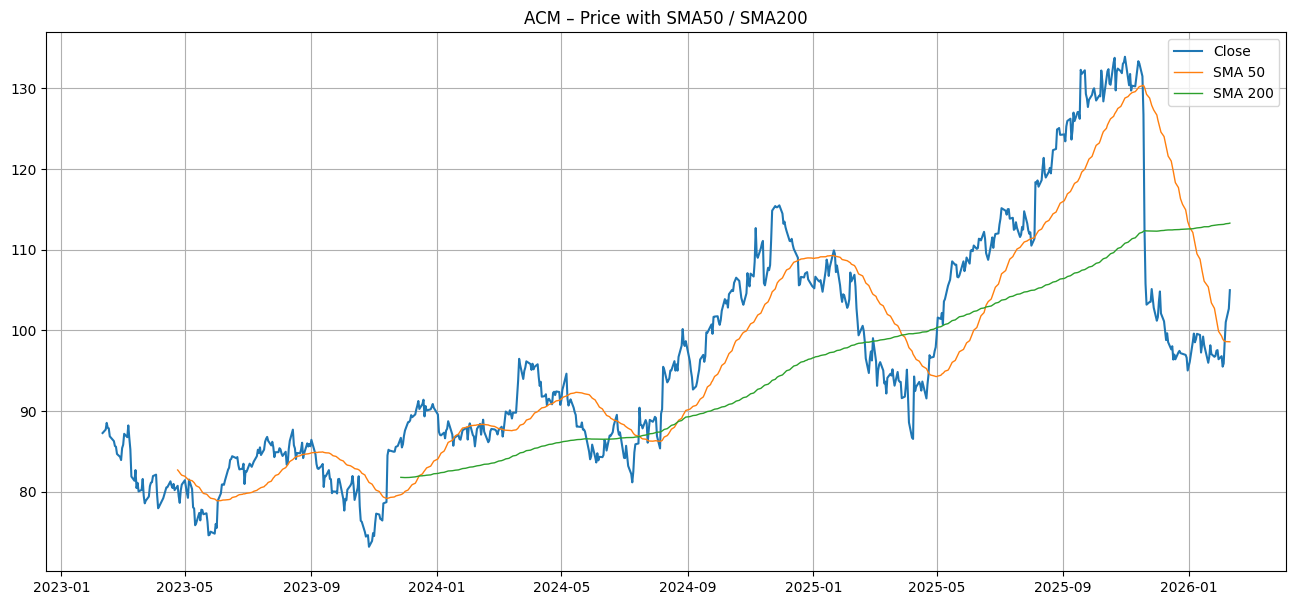

C:\Users\Linus\AppData\Local\Temp\ipykernel_18784\236356486.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_1y = yf.download(ticker, period="1y")
[*********************100%***********************]  1 of 1 completed


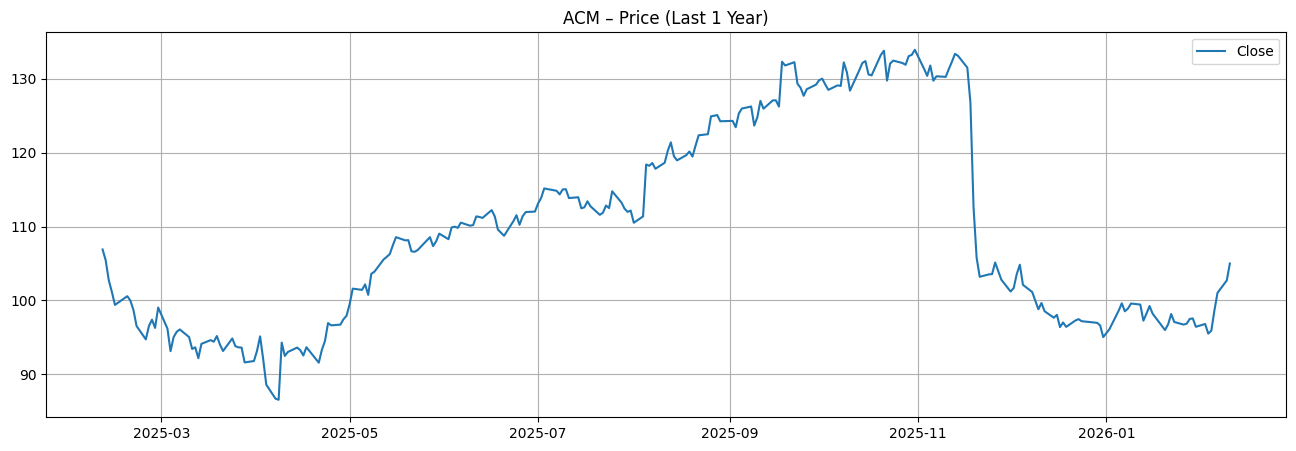

In [5]:
# Load historical data (multi-year)
df10 = yf.download(TICKER, period="3y")
df10.index = df10.index.tz_localize(None)

# Calculate SMAs
df10 = calculate_sma(df10, windows=(50, 200))

# Plot and save figures
plot_price_with_sma(
    df10,
    ticker=TICKER,
    save_path=f"figures/{TICKER}_price_with_sma.png"
)

plot_price_last_year(
    ticker=TICKER,
    save_path=f"figures/{TICKER}_price_last_year.png"
)
